# Import libraries and get data

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# CONFIGURACIÓN DEL PORTAFOLIO
# ------------------------------------------------------------

# Lista de activos que componen el portafolio
assets = ['AAPL', 'MSFT']           # Apple y Microsoft

# Pesos del portafolio:
# 60% invertido en AAPL y 40% en MSFT
weights = np.array([0.6, 0.4])

# Periodo histórico a analizar
start_date = "2020-01-01"
end_date   = "2025-01-01"

# ------------------------------------------------------------
# DESCARGA DE DATOS HISTÓRICOS
# ------------------------------------------------------------

# Descarga precios ajustados automáticamente:
# - incluye splits
# - incluye dividendos
raw = yf.download(
    assets,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

# ------------------------------------------------------------
# SELECCIÓN ROBUSTA DE PRECIOS DE CIERRE
# ------------------------------------------------------------

# yfinance puede devolver:
# - columnas MultiIndex (varios activos)
# - columnas simples (un activo)
# Este bloque maneja ambos casos
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw['Close'].copy()       # columnas = tickers
else:
    prices = raw[['Close']].copy()     # fallback para un solo activo

# ------------------------------------------------------------
# CÁLCULO DE RETORNOS DIARIOS
# ------------------------------------------------------------

# Retornos porcentuales diarios
# (base para riesgo, Monte Carlo y Markowitz)
returns = prices.pct_change().dropna()

# ------------------------------------------------------------
# ESTADÍSTICAS BÁSICAS DEL PORTAFOLIO
# ------------------------------------------------------------

# Retorno promedio diario por activo
mean_returns = returns.mean()

# Matriz de covarianza diaria entre los activos
# Captura cómo se mueven juntos (diversificación)
cov_matrix = returns.cov()

# Muestra resultados
print("Mean daily returns:\n", mean_returns)
print("\nCovariance matrix:\n", cov_matrix)


Mean daily returns:
 Ticker
AAPL    0.001182
MSFT    0.000988
dtype: float64

Covariance matrix:
 Ticker      AAPL      MSFT
Ticker                    
AAPL    0.000398  0.000287
MSFT    0.000287  0.000369


# Monte Carlo simulation function

In [3]:
def monte_carlo_simulation(mean_returns, cov_matrix, weights, num_simulations, days):
    # ------------------------------------------------------------
    # mean_returns:
    #   vector de retornos promedio diarios por activo
    #
    # cov_matrix:
    #   matriz de covarianza diaria entre activos
    #
    # weights:
    #   pesos del portafolio (suman 1)
    #
    # num_simulations:
    #   número de escenarios Monte Carlo a generar
    #
    # days:
    #   horizonte temporal de la simulación (en días de trading)
    # ------------------------------------------------------------

    # Array para almacenar el retorno acumulado final
    # de cada simulación
    results = np.zeros(num_simulations)

    # ------------------------------------------------------------
    # Bucle principal de Monte Carlo
    # Cada iteración representa "un posible año"
    # ------------------------------------------------------------
    for i in range(num_simulations):

        # Genera una matriz [days x n_assets] de retornos diarios simulados
        # asumiendo una distribución normal multivariada
        simulated_returns = np.random.multivariate_normal(
            mean_returns,    # medias diarias
            cov_matrix,      # dependencia entre activos
            days             # número de días simulados
        )

        # Calcula los retornos diarios del portafolio
        # combinando retornos simulados y pesos
        portfolio_returns = simulated_returns.dot(weights)

        # Calcula el retorno acumulado del periodo:
        # (1+r1)*(1+r2)*...*(1+r_days) - 1
        cumulative_return = np.prod(1 + portfolio_returns) - 1

        # Guarda el resultado final de esta simulación
        results[i] = cumulative_return

    # Devuelve un vector con la distribución
    # de retornos acumulados simulados
    return results


# ------------------------------------------------------------
# EJECUCIÓN DE LA SIMULACIÓN
# ------------------------------------------------------------

# Número de escenarios Monte Carlo
num_simulations = 100000

# Horizonte temporal: 252 días ≈ 1 año de trading
days = 252

# Corre la simulación para el portafolio definido
simulated_results = monte_carlo_simulation(
    mean_returns,
    cov_matrix,
    weights,
    num_simulations,
    days
)

# Analyse risk metrics

VaR(95%): -21.64%
CVaR(95%): -30.22%


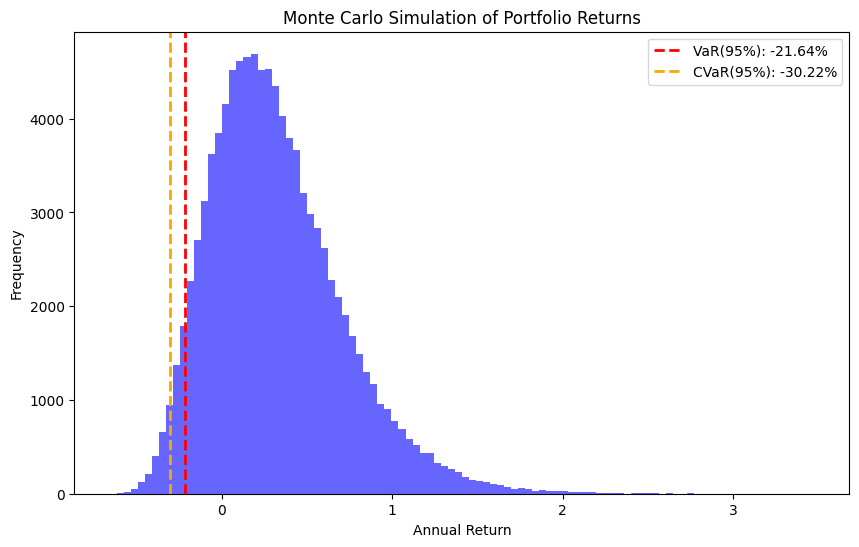

In [ ]:
# ------------------------------------------------------------
# VALUE AT RISK (VaR) AL 95%
# ------------------------------------------------------------

# El VaR al 95% es el percentil 5 de la distribución de retornos:
# indica la pérdida (o retorno bajo) que solo se supera en el 5% de los peores escenarios
VaR_95 = np.percentile(simulated_results, 5)

# ------------------------------------------------------------
# CONDITIONAL VALUE AT RISK (CVaR) / EXPECTED SHORTFALL
# ------------------------------------------------------------

# El CVaR al 95% es el promedio de los retornos
# que son PEOR o IGUAL al VaR:
# mide la severidad de las pérdidas extremas
CVaR_95 = simulated_results[simulated_results <= VaR_95].mean()

# ------------------------------------------------------------
# RESULTADOS
# ------------------------------------------------------------

# VaR: umbral de pérdida extrema
print(f"VaR(95%): {VaR_95:.2%}")

# CVaR: pérdida promedio cuando las cosas salen muy mal
print(f"CVaR(95%): {CVaR_95:.2%}")


# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(simulated_results, bins=100, alpha=0.6, color='blue')
plt.axvline(VaR_95, color='red', linestyle='dashed', linewidth=2, label=f'VaR(95%): {VaR_95:.2%}')
plt.axvline(CVaR_95, color='orange', linestyle='dashed', linewidth=2, label=f'CVaR(95%): {CVaR_95:.2%}')
plt.title('Monte Carlo Simulation of Portfolio Returns')
plt.xlabel('Annual Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()


# VaR(95%) = −21.64%

# En el 95% de los escenarios simulados, la pérdida anual no supera el 21.64%.

# Pero en el 5% peor de los casos, la pérdida es peor que −21.64%.

# CVaR(95%) = −30.22%

# Si ocurre ese 5% de escenarios realmente malos,
# la pérdida promedio es de −30.22%.

# Esto mide la severidad del riesgo extremo, no solo el umbral.